# 3. Análise Exploratória de Dados (EDA) e Visualização

**Pergunta de Negócio:** *"Qual marca possui os preços mais em conta?"*  
**Base Utilizada:** `data/dados_tratados.csv`

**Objetivos:**
1. Carregar os dados higienizados do Módulo 2
2. Calcular estatísticas descritivas gerais e por fabricante (Média, Mediana, Mínimo, Máximo e Desvio Padrão)
3. Identificar a marca com o menor preço médio e o modelo de menor custo absoluto
4. Gerar gráficos explicativos (Barras e Boxplot) utilizando Matplotlib e Seaborn
5. Registrar os insights finais para o relatório executivo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Carregar dados tratados do Módulo 2
caminho_tratado = "../data/dados_tratados.csv"
df = pd.read_csv(caminho_tratado)

print(f"✅ Base tratada carregada com sucesso!")
print(f"• Total de Smart TVs analisadas: {len(df)}")
print(f"• Fabricantes identificados: {df['marca'].nunique()} ({', '.join(df['marca'].unique())})\n")

df.head()

✅ Base tratada carregada com sucesso!
• Total de Smart TVs analisadas: 17
• Fabricantes identificados: 5 (TCL, LG, Samsung, Outras, Philco)



,id_produto,marca,produto,preco,loja_oferta,url,categoria
0,1,TCL,"Smart TV Mini LED 55"" TCL 4K 55C6K",3279.00,Via Amazon,NaN,Smart TV
1,2,TCL,"Smart TV QD-Mini LED 65"" TCL 4K 65C6K",3963.60,Via Webcontinental,NaN,Smart TV
2,3,LG,"Smart TV LED 50"" LG 4K UA7500",2230.41,Via Magazine Luiza,NaN,Smart TV
3,4,TCL,"Smart TV QLED 50"" TCL 4K P7K",2069.10,Via Magazine Luiza,NaN,Smart TV
4,5,TCL,"Smart TV QD-Mini LED 75"" TCL 4K C6K",5859.73,Via Magazine Luiza,NaN,Smart TV


## 3.1 Agrupamento Estatístico por Marca

Nesta etapa, calculamos a **quantidade de opções**, **preço médio**, **mediana**, **preço mínimo** e **preço máximo** de cada fabricante para responder à pergunta de negócio: *"Qual marca possui os preços mais em conta?"*.

In [5]:
# Agrupamento por marca com métricas estatísticas
df_estatisticas = df.groupby('marca')['preco'].agg(
    quantidade='count',
    preco_medio='mean',
    mediana='median',
    preco_minimo='min',
    preco_maximo='max',
    desvio_padrao='std'
).reset_index()

# Ordenar pelo menor preço médio
df_estatisticas = df_estatisticas.sort_values(by='preco_medio', ascending=True).reset_index(drop=True)

# Arredondar valores monetários
colunas_moeda = ['preco_medio', 'mediana', 'preco_minimo', 'preco_maximo', 'desvio_padrao']
df_estatisticas[colunas_moeda] = df_estatisticas[colunas_moeda].round(2)

print("--- Tabela Comparativa de Preços por Marca (Ordenada do mais barato ao mais caro) ---")
display(df_estatisticas)

# Identificar a marca com o menor preço médio
marca_mais_barata = df_estatisticas.iloc[0]['marca']
preco_medio_mais_barato = df_estatisticas.iloc[0]['preco_medio']

# Identificar o produto individual mais barato de toda a base
tv_mais_barata = df.loc[df['preco'].idxmin()]

print("\n🎯 RESPOSTA À PERGUNTA DE NEGÓCIO:")
print(f"• Marca com menor preço médio: {marca_mais_barata} (Média de R$ {preco_medio_mais_barato:,.2f})")
print(f"• Modelo individual mais barato: {tv_mais_barata['produto']} ({tv_mais_barata['marca']}) por R$ {tv_mais_barata['preco']:,.2f}")

--- Tabela Comparativa de Preços por Marca (Ordenada do mais barato ao mais caro) ---


,marca,quantidade,preco_medio,mediana,preco_minimo,preco_maximo,desvio_padrao
0,Philco,1,889.00,889.00,889.00,889.00,NaN
1,Outras,2,2250.03,2250.03,2198.00,2302.06,73.58
2,Samsung,5,3585.08,2374.91,1612.80,6031.55,2159.72
3,TCL,6,4120.70,3766.15,2069.10,5984.05,1532.53
4,LG,3,4778.04,5851.05,2230.41,6252.66,2215.43



🎯 RESPOSTA À PERGUNTA DE NEGÓCIO:
• Marca com menor preço médio: Philco (Média de R$ 889.00)
• Modelo individual mais barato: Smart TV LED 32" Philco PTV32K34RKGB (Philco) por R$ 889.00


## 3.2 Visualização de Dados (Gráficos)

Geração de gráficos com **Seaborn** e **Matplotlib** para ilustrar a comparação entre marcas e a variação de preços no mercado de Smart TVs.

C:\Users\Daniel\AppData\Local\Temp\ipykernel_14296\3898633029.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


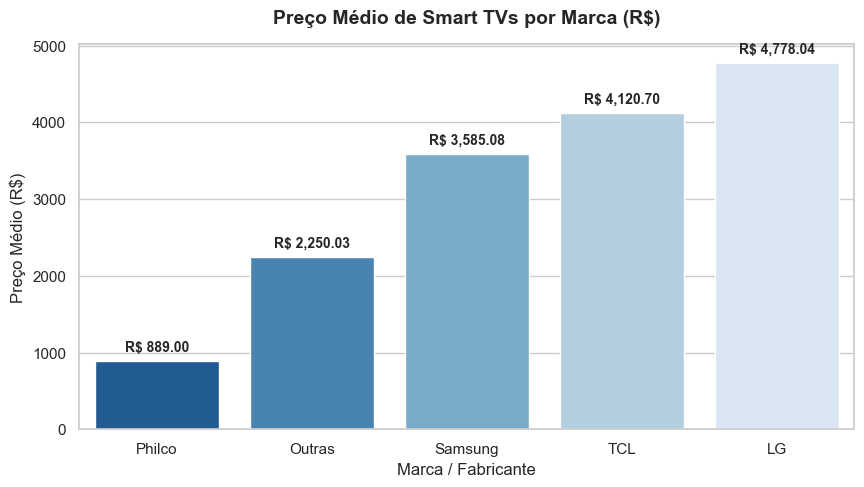

In [6]:
# Criar a figura

plt.figure(figsize=(10, 5))

# Gráfico de barras ordenado
ax = sns.barplot(
    data=df_estatisticas,
    x='marca',
    y='preco_medio',
    palette='Blues_r'
)

# Títulos e rótulos
plt.title('Preço Médio de Smart TVs por Marca (R$)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Marca / Fabricante', fontsize=12)
plt.ylabel('Preço Médio (R$)', fontsize=12)

# Adicionar o valor numérico em cima de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f'R$ {altura:,.2f}',
            (p.get_x() + p.get_width() / 2., altura),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 5), textcoords='offset points'
        )

# Salvar a imagem do gráfico
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/preco_medio_por_marca.png", bbox_inches='tight', dpi=300)

plt.show()

C:\Users\Daniel\AppData\Local\Temp\ipykernel_14296\767694282.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


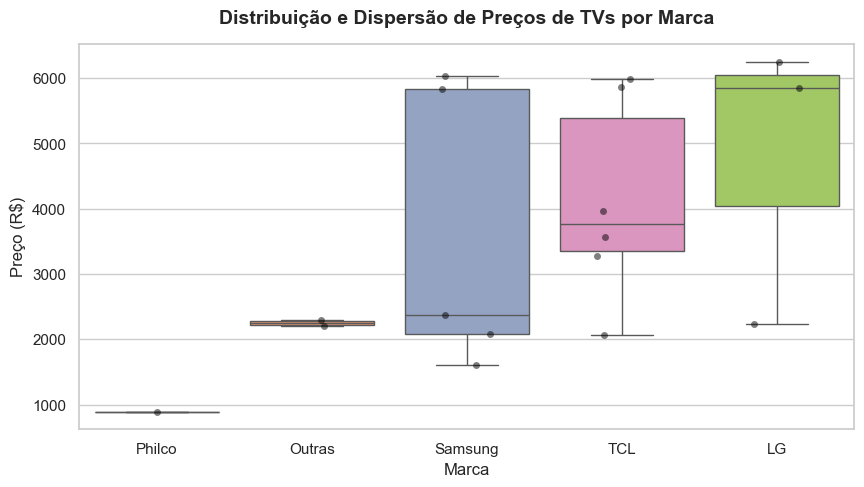

In [7]:
# Criar a figura
plt.figure(figsize=(10, 5))

# Ordenar as marcas no boxplot conforme a média
ordem_marcas = df_estatisticas['marca'].tolist()

# Gráfico Boxplot
sns.boxplot(
    data=df,
    x='marca',
    y='preco',
    order=ordem_marcas,
    palette='Set2'
)

# Adicionar os pontos individuais (strip plot) sobre o boxplot
sns.stripplot(
    data=df,
    x='marca',
    y='preco',
    order=ordem_marcas,
    color='black',
    alpha=0.5,
    jitter=0.2
)

plt.title('Distribuição e Dispersão de Preços de TVs por Marca', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)

# Salvar o gráfico
plt.savefig("../reports/figures/distribuicao_precos_boxplot.png", bbox_inches='tight', dpi=300)

plt.show()